In [1]:
from typing import Literal

from langchain.chat_models import init_chat_model
from langchain.tools import tool
from langchain_core.messages import HumanMessage, SystemMessage, ToolMessage
from langgraph.constants import START, END
from langgraph.graph import StateGraph, MessagesState
from dotenv import load_dotenv
load_dotenv()


# ====== Step 1: 准备工具 ======
# 工具
@tool
def get_weather(city: str) -> str:
    """获取城市天气"""
    weather_data = {
        "北京": "晴天 25度",
        "上海": "多云 28度",
        "杭州": "小雨 22度",
    }
    return weather_data.get(city, f"未找到{city}的天气信息")

@tool
def square_root(x: float) -> str:
    """Calculate the square root of a number"""
    return x ** 0.5

# 工具数组写好
tools = [get_weather, square_root]

# 组成工具名和工具的映射，方便查找工具
# 字典表达式
# 工具列表中key为函数名,值为真正的函数引用
tools_by_name = {tool.name: tool for tool in tools}

In [2]:
"""
    这个定义好的工具,需要添加到模型对象身上绑定进去
"""
# 这个初始化模型的包是来自于langchain,所以不能挂载工具
model = init_chat_model(
    model='deepseek-v4-flash',
    extra_body = {'thinking': {'type': 'disabled'}},
)

# 挂载工具,返回挂载工具后的模型对象
model_with_tools = model.bind_tools(tools)

In [3]:
"""
    定义工具调用节点
"""
# 这个state是写好的追加消息列表的类
def tool_node(state: MessagesState):
    # 获取返回的最后一条消息列表,是工具调用列表
    message = state['messages'][-1]
    # 定义存储工具调用返回值的列表
    tool_results = []

    # 循环工具消息
    for tool_call in message.tool_calls:
        # 本轮执行的工具信息
        _fn_name = tool_call['name']
        _args = tool_call['args']
        _id = tool_call['id']

        # 调用工具
        # 工具函数被tool装饰器装饰后变成了对象,可以通过invoke调用
        result =  tools_by_name[_fn_name].invoke(_args)

        # 将工具函数的返回结果封装成工具消息对象存入列表
        tool_results.append(ToolMessage(content=result, tool_call_id = _id))

    # 返回调用工具函数节点的执行结果给大模型
    return {
        "messages":tool_results
    }

# 调用大模型的节点
def llm_node(state: MessagesState):
    # 通过state拿到全部的会话历史
    response = model_with_tools.invoke(
        # 将会话列表传递进去
        state['messages']
    )
    return {
        # MessagesState的追加函数要求必须是一个列表
        "messages":[response]
    }

# 路由函数,识别是否需要工具调用
def should_router(state: MessagesState):
    tool_message = state['messages'][-1]
    # 看看最后一条消息是否有东西
    # hasattr(object, name) 检查某个对象是否有某个方法或者属性
    if hasattr(tool_message, 'tool_calls')  and tool_message.tool_calls:
        return 'tools'
    return END

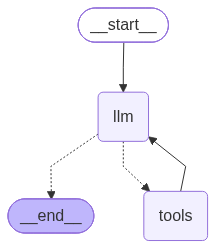

In [4]:
from IPython.core.display import display_png, Image
from langgraph.prebuilt import ToolNode, tools_condition

"""
    构建Graph图进行测试
"""
graph_builder = StateGraph(MessagesState)

# 添加节点
graph_builder.add_node('llm',llm_node)
# 添加工具节点
graph_builder.add_node('tools',tool_node)

# 连线
graph_builder.add_edge(START,'llm')
# llm接下来走到意图识别节点
graph_builder.add_conditional_edges('llm',should_router, {"tools": "tools", END: END})
# 工具节点如果执行了,回到大模型节点
graph_builder.add_edge('tools','llm')

# 创建图
agent_graph =  graph_builder.compile()
display_png(Image(agent_graph.get_graph().draw_mermaid_png()))

In [5]:
# 调用
result = agent_graph.invoke({
    "messages": [HumanMessage(content="北京和杭州今天天气怎么样？")]
})
for m in result['messages']:
    m.pretty_print()

================================ Human Message =================================

北京和杭州今天天气怎么样？
================================== Ai Message ==================================

我来帮您查询北京和杭州今天的天气情况。
Tool Calls:
  get_weather (call_00_TBl6KH3foXgL3Qxj5zFw3695)
 Call ID: call_00_TBl6KH3foXgL3Qxj5zFw3695
  Args:
    city: 北京
  get_weather (call_01_DkgnLfAuBSPMAlfV1S2U1217)
 Call ID: call_01_DkgnLfAuBSPMAlfV1S2U1217
  Args:
    city: 杭州
================================= Tool Message =================================

晴天 25度
================================= Tool Message =================================

小雨 22度
================================== Ai Message ==================================

查询结果如下：

- **北京**：☀️ 晴天，**25℃**
- **杭州**：🌧️ 小雨，**22℃**

北京天气晴朗温暖，适合户外活动；杭州有小雨，出门记得带上雨具哦！
